# Text generation with structured output

In [5]:
import os
import json
from pydantic import BaseModel, Field
from typing import List, Optional
from google import genai
from google.genai import types
from dotenv import load_dotenv

load_dotenv()

# Define the structure for our narrative entities
class Character(BaseModel):
    name: str = Field(description="Full name of the character")
    archetype: str = Field(description="Role in the story (e.g., Hero, Shadow)")
    traits: List[str] = Field(description="Personality traits")

class StoryOutput(BaseModel):
    title: str
    summary: str
    characters: List[Character]
    estimated_reading_time: int = Field(description="Time in minutes")

# Initialize Client with Vertex AI configuration
client = genai.Client(
    vertexai=True,
    project=os.environ.get("GOOGLE_CLOUD_PROJECT", "challengegemini"),
    location="us-central1"
)

# Execution of structured request
prompt = "Design a high-fantasy story concept about a blacksmith who finds a dragon's egg."

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt,
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=StoryOutput,
        temperature=0.7,
    ),
)

# Print the full story output
story = response.parsed
print("Title:", story.title)
print("\nSummary:", story.summary)
print("\nCharacters:")
for c in story.characters:
    print(f"  - {c.name} ({c.archetype}): {', '.join(c.traits)}")
print(f"\nEstimated reading time: {story.estimated_reading_time} min")

Title: The Dragon's Forge

Summary: Kaelen Stonehand, a reclusive but master blacksmith in the secluded village of Oakhaven, stumbles upon a peculiar, obsidian-like 'ore' deep within the Dragon's Tooth mountains. Unbeknownst to him, it is a dragon's egg, long thought to be extinct. When the egg hatches in his forge, revealing a vibrant, intelligent wyrmling, Kaelen's quiet life is irrevocably shattered. He forms an unlikely bond with the creature, naming it Ignis, and is soon thrust into a perilous world of ancient prophecies, warring factions seeking to control or destroy the last dragon, and the forgotten history of his own land.

Characters:
  - Kaelen Stonehand (Reluctant Hero): Resourceful, Stubborn, Compassionate, Solitary, Skilled craftsman
  - Ignis (Catalyst): Playful, Fiercely loyal, Rapidly growing, Intelligent, Curious
  - Lord Valerius Thorne (Shadow): Ambitious, Ruthless, Manipulative, Dragon hunter, Authoritarian
  - Elara Vancroft (Mentor): Knowledgeable, Enigmatic, Pro

# image generation Nano Banana

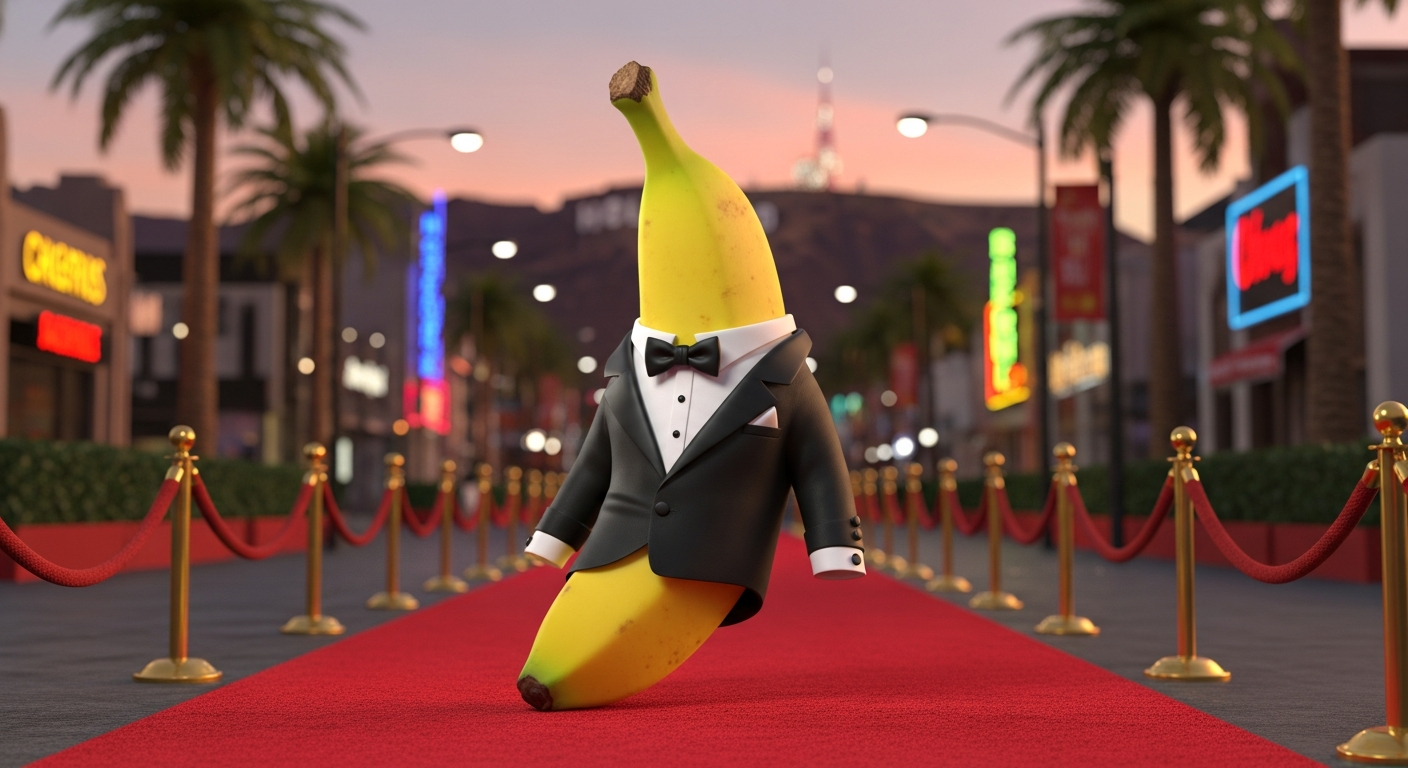

In [32]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()

PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "challengegemini")
LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

prompt = "A vibrant, cinematic 3D render of a banana wearing a tuxedo on a red carpet in Hollywood."

result = client.models.generate_images(
    model="imagen-4.0-generate-001",
    prompt=prompt,
    config=types.GenerateImagesConfig(
        number_of_images=1,
        aspect_ratio="16:9",
        image_size="1K",
        person_generation="ALLOW_ADULT",
        safety_filter_level="BLOCK_MEDIUM_AND_ABOVE",
        # add_watermark defaults to True in many examples; set explicitly if you want
        add_watermark=True,
    ),
)

img = result.generated_images[0].image._pil_image  # PIL.Image
img.save("imagen4_ref.png")
img


# image generation Nano Banana with reference image

# Video generation with reference image

In [33]:
import os
import time
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()

PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "challengegemini")
LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

prompt = "A cinematic, high-detail shot of a tiny astronaut skating on a frozen puddle in a neon-lit city at night, with subtle wind and ambient city sounds."

operation = client.models.generate_videos(
    model="veo-3.1-generate-001",
    prompt=prompt,
    config=types.GenerateVideosConfig(
        number_of_videos=1,
        duration_seconds=6,
        aspect_ratio="16:9",
        resolution="720p",
        enhance_prompt=True,
        generate_audio=True,          # required for Veo 3 models
        person_generation="allow_adult",
        # If you prefer output to Cloud Storage, add:
        # output_gcs_uri="gs://YOUR_BUCKET/some/prefix/"
    ),
)

while not operation.done:
    time.sleep(15)
    operation = client.operations.get(operation)

video_bytes = operation.result.generated_videos[0].video.video_bytes
with open("veo31_ref.mp4", "wb") as f:
    f.write(video_bytes)

"Saved veo31_ref.mp4"


'Saved veo31_ref.mp4'

# Text to Speech

In [43]:
# pip/uv:
# uv pip install google-cloud-texttospeech

import os
from dotenv import load_dotenv
from google.cloud import texttospeech

load_dotenv()

tts_client = texttospeech.TextToSpeechClient()

def tts_to_mp3(
    text: str,
    out_path: str = "narration.mp3",
    voice_name: str = "en-US-Journey-D",   # change to an Arabic voice if you want
    speaking_rate: float = 1.0,
    pitch: float = 0.0,
):
    synthesis_input = texttospeech.SynthesisInput(
        ssml=f"<speak>{text}</speak>"
    )

    voice = texttospeech.VoiceSelectionParams(
        language_code="en-US",
        ssml_gender=texttospeech.SsmlVoiceGender.NEUTRAL,
    )

    audio_config = texttospeech.AudioConfig(
        audio_encoding=texttospeech.AudioEncoding.MP3,
        speaking_rate=speaking_rate,
        pitch=pitch,
    )

    resp = tts_client.synthesize_speech(
        input=synthesis_input, voice=voice, audio_config=audio_config
    )

    with open(out_path, "wb") as f:
        f.write(resp.audio_content)

    return out_path

story_ssml = """
<prosody rate="medium">
Tonight, the city lights shimmered like stars on the water.
</prosody>
<break time="500ms"/>
<prosody rate="medium">
Our hero took a deep breath, and stepped into the unknown.
</prosody>
"""

print("Saved:", tts_to_mp3(story_ssml, "story_narration.mp3"))

Saved: story_narration.mp3
